# Built Different? What the Data Really Says About Winning in the UFC

*Every UFC fan has a theory. "It's all about the reach." "Heavyweights just need one punch." "You can't teach size." But what happens when we stop debating and start counting? We analysed over 2,200 UFC fights to find out what actually separates winners from losers — and the answers might surprise you.*

## Introduction

The UFC is the world's biggest mixed martial arts organisation, where fighters from every discipline — boxing, wrestling, jiu-jitsu, muay thai — compete against each other in an eight-sided cage. With weight classes ranging from 52 kg strawweights to 120 kg heavyweights, the sport creates a natural laboratory for a question that has fascinated fight fans for decades: **what actually predicts who wins?**

Common wisdom says taller fighters have a reach advantage, heavier fighters hit harder, and younger fighters have the edge in athleticism. But conventional wisdom is often wrong. In this post, we use data from 2,228 UFC fights (spanning 2014–2018) to test these assumptions. We'll look at how fights end across different weight classes, whether being taller genuinely helps, and what statistics truly separate elite fighters from the rest. Finally, we'll build a statistical model to predict fight outcomes — and examine the fighters who defy the numbers.

Let's step into the Octagon.

## The Data

The dataset comes from a comprehensive UFC statistics collection on Kaggle, originally covering 2,318 fights from February 2014 to December 2018. After cleaning — removing draws, no-contests, and fights with missing outcomes, and aggregating round-by-round statistics into fight totals — we work with **2,228 decisive fights**. Of these, 1,837 have complete round-by-round performance statistics (strikes, takedowns, control time, and so on).

Each fight record contains both fighters' physical attributes (height, weight, age), their fight outcomes (winner, method of victory), and detailed performance metrics: significant strikes landed and attempted, takedowns, knockdowns, submission attempts, and control time. The cleaning script also creates derived "difference" features — e.g. `height_diff`, `sig_strike_diff` — that compare the two fighters directly in each bout.

One note: the original dataset does not include reach measurements, so we use **height** (and height difference) as a proxy for reach. Height and reach are strongly correlated in fighters, so this is a reasonable substitution.

In [4]:
# ============================================================
# SECTION 2: Data Exploration
# ============================================================
import pandas as pd

# Load the raw dataset
df = pd.read_csv('data/raw/ufcdataset.csv')

# --- How big is the dataset? ---
print(f"Rows: {df.shape[0]}")        # 2,318 fights
print(f"Columns: {df.shape[1]}")     # 894 columns (lots of round-by-round detail)

# --- What are the key (non-round) columns? ---
key_cols = [c for c in df.columns if '_Round' not in c]
print(f"\nKey columns ({len(key_cols)}):")
for c in key_cols:
    print(f"  {c}")

# --- First 5 rows (key columns only) ---
df[key_cols].head()

Rows: 2318
Columns: 894

Key columns (24):
  BPrev
  BStreak
  B_Age
  B_Height
  B_HomeTown
  B_ID
  B_Location
  B_Name
  B_Weight
  Date
  Event_ID
  Fight_ID
  Last_round
  Max_round
  RPrev
  R_Age
  R_Height
  R_HomeTown
  R_ID
  R_Location
  R_Name
  R_Weight
  winby
  winner


,BPrev,BStreak,B_Age,B_Height,B_HomeTown,B_ID,B_Location,B_Name,B_Weight,Date,...,RPrev,R_Age,R_Height,R_HomeTown,R_ID,R_Location,R_Name,R_Weight,winby,winner
0,0,0,38.0,193.0,Hounslow England,808,Amsterdam The Netherlands,Alistair Overeem,120.0,02/03/2014,...,0,39.0,190.0,"Las Vegas, Nevada USA",377,"Las Vegas, Nevada USA",Frank Mir,119.0,DEC,blue
1,0,0,36.0,172.0,"Chicago, Illinois United States",1054,"Chicago, Illinois United States",Ricardo Lamas,65.0,02/03/2014,...,0,32.0,170.0,Manaus Brazil,1052,Rio de Janeiro Brazil,Jose Aldo,65.0,DEC,red
2,0,0,39.0,167.0,"Isla Vista , California USA",959,"Sacramento, California USA",Urijah Faber,61.0,02/03/2014,...,0,31.0,167.0,Natal Brazil,1527,Rio de Janeiro Brazil,Renan Barao,61.0,KO/TKO,red
3,0,0,33.0,167.0,"San Diego, CA USA",1056,"San Diego, CA USA",Danny Martinez,56.0,02/03/2014,...,0,37.0,160.0,"San Jose, California USA",1253,"Tucson, Arizona USA",Chris Cariaso,56.0,DEC,red
4,0,0,36.0,185.0,Southampton England,2005,Southampton England,Tom Watson,84.0,02/03/2014,...,0,37.0,182.0,"Englewood, NJ USA",464,"Brick, NJ USA",Nick Catone,84.0,DEC,red


In [5]:
# --- Missing values for key columns ---
missing = df[key_cols].isnull().sum()
missing[missing > 0]

B_Age         17
B_Height      17
B_HomeTown    17
B_Location    13
B_Weight      12
R_Age         26
R_Height      24
R_HomeTown    25
R_Location    24
R_Weight      22
winby         36
dtype: int64

In [6]:
# --- Data types ---
df[key_cols].dtypes

BPrev           int64
BStreak         int64
B_Age         float64
B_Height      float64
B_HomeTown     object
B_ID            int64
B_Location     object
B_Name         object
B_Weight      float64
Date           object
Event_ID        int64
Fight_ID        int64
Last_round      int64
Max_round       int64
RPrev           int64
R_Age         float64
R_Height      float64
R_HomeTown     object
R_ID            int64
R_Location     object
R_Name         object
R_Weight      float64
winby          object
winner         object
dtype: object

In [7]:
# --- Fight outcome distributions ---
print("Winner (corner colour):")
print(df['winner'].value_counts())
print("\nWin method:")
print(df['winby'].value_counts())

Winner (corner colour):
winner
red           1327
blue           951
no contest      24
draw            16
Name: count, dtype: int64

Win method:
winby
DEC       1111
KO/TKO     744
SUB        427
Name: count, dtype: int64


In [8]:
# --- Weight class mapping ---
# Weights are in kg — these map to standard UFC divisions
weight_map = {
    52: 'Strawweight', 56: 'Flyweight', 61: 'Bantamweight',
    65: 'Featherweight', 70: 'Lightweight', 77: 'Welterweight',
    84: 'Middleweight', 93: 'Light Heavyweight', 120: 'Heavyweight'
}
df['weight_class'] = df['B_Weight'].map(
    lambda x: weight_map.get(int(x)) if pd.notna(x) and int(x) in weight_map else 'Other'
)
print(df['weight_class'].value_counts())

weight_class
Welterweight         417
Lightweight          407
Bantamweight         306
Middleweight         259
Featherweight        251
Flyweight            209
Light Heavyweight    188
Other                124
Strawweight          117
Heavyweight           40
Name: count, dtype: int64


## Setup for the Analysis

Before plotting anything, we load the cleaned dataset and set up a consistent visual style that will be used across every chart in this post. Consistent colours make a blog post feel professional — the same three colours will represent KO/TKO, Submission, and Decision throughout.

In [14]:
# ── Imports and load cleaned data ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style across the whole notebook
plt.style.use('seaborn-v0_8-whitegrid')

# Consistent colour palette used in every plot
COLORS = {
    'primary':   '#E63946',  # Red — KO/TKO, emphasis
    'secondary': '#457B9D',  # Blue — Submission / secondary
    'tertiary':  '#2A9D8F',  # Teal — Decision
    'accent':    '#F4A261',  # Amber — highlights
    'dark':      '#1D3557',  # Dark navy — text / headers
}
METHOD_COLORS = {
    'KO/TKO':     COLORS['primary'],
    'Submission': COLORS['secondary'],
    'Decision':   COLORS['tertiary'],
}

# Ensure output folder exists for saved figures
os.makedirs('output/figures', exist_ok=True)

# Load the cleaned dataset produced by Section 3
df = pd.read_csv('data/cleaned/ufc_cleaned.csv')
print(f"Cleaned dataset loaded: {df.shape[0]} fights, {df.shape[1]} columns")
print(f"Fights with detailed round stats: {(df['r_sig_strikes_attempted'] > 0).sum()}")

# Display order for weight classes (lightest to heaviest)
wc_order = ['Strawweight', 'Flyweight', 'Bantamweight', 'Featherweight',
            'Lightweight', 'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']

Cleaned dataset loaded: 2228 fights, 59 columns
Fights with detailed round stats: 1837


## How Do Fights End? The Weight Class Effect

If you've ever watched a heavyweight fight, you know the feeling — every exchange carries the threat of sudden ending. But just how dramatic is the difference between weight classes when it comes to *how* fights are decided? We broke down the proportion of KO/TKO, submission, and decision wins across all nine UFC weight classes.

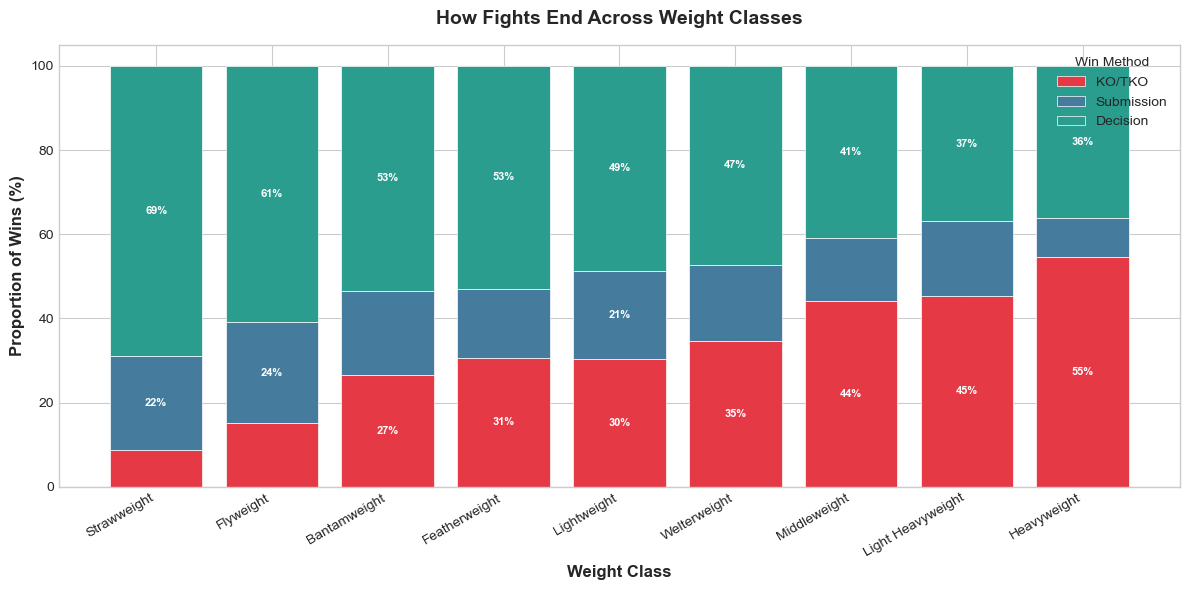

In [17]:
# ── Plot 1: Win Methods by Weight Class (Stacked Bar Chart) ──
fig, ax = plt.subplots(figsize=(12, 6))

# Proportion of each win method within each weight class
wc_method = df.groupby(['weight_class', 'win_method']).size().unstack(fill_value=0)
wc_method = wc_method.reindex(wc_order)
wc_method_pct = wc_method.div(wc_method.sum(axis=1), axis=0) * 100

# Build stacked bars: KO/TKO on the bottom, Submission in the middle, Decision on top
methods = ['KO/TKO', 'Submission', 'Decision']
bottom = np.zeros(len(wc_order))
for method in methods:
    vals = wc_method_pct[method].values
    ax.bar(wc_order, vals, bottom=bottom, color=METHOD_COLORS[method],
           label=method, edgecolor='white', linewidth=0.5)
    # Label segments larger than 20%
    for i, v in enumerate(vals):
        if v > 20:
            ax.text(i, bottom[i] + v / 2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottom += vals

ax.set_xlabel('Weight Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of Wins (%)', fontsize=12, fontweight='bold')
ax.set_title('How Fights End Across Weight Classes', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Win Method', loc='upper right', framealpha=0.9)
ax.set_xticklabels(wc_order, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/figures/plot1_win_methods_by_weight.png', dpi=150, bbox_inches='tight')
plt.show()

The pattern is striking — and it runs exactly in the direction you'd expect if you're a fight fan, but with some twists. At **heavyweight, around 54% of fights end in KO/TKO**, while only a third go to the judges. Compare that with **strawweight, where roughly 69% of fights go to decision** and barely 9% end in knockout. The trend is remarkably consistent: as fighters get bigger, the knockout rate climbs steadily.

But the submission story is more interesting. Submissions peak at the **lighter weight classes** — flyweight and bantamweight — where around 23% of fights end on the mat. This makes intuitive sense: lighter fighters tend to be more agile on the ground and can more easily execute the sweeps and transitions that lead to chokes and joint locks. By the time you reach heavyweight, submissions account for only about 10% of victories.

What this tells us is that the UFC isn't one sport — it's really several sports wearing the same logo. A flyweight contest is fundamentally a different kind of athletic event from a heavyweight bout, and the data bears this out. If you're betting on a heavyweight fight, history says there's a coin-flip chance someone's getting knocked out. At strawweight, settle in — you're probably going the distance.

## Does Height Actually Help?

One of the oldest debates in combat sports is whether being taller gives a fighter a meaningful advantage. The theory is simple: taller fighters can hit their opponents from further away while staying out of range. But fighting isn't boxing — in MMA, a taller fighter can be taken down, clinched up, or find their length neutralised by an aggressive shorter opponent. So what does the data say?

We measured the height difference between the two fighters in each fight, grouped them into 5 cm buckets, and calculated the win rate at each height gap.

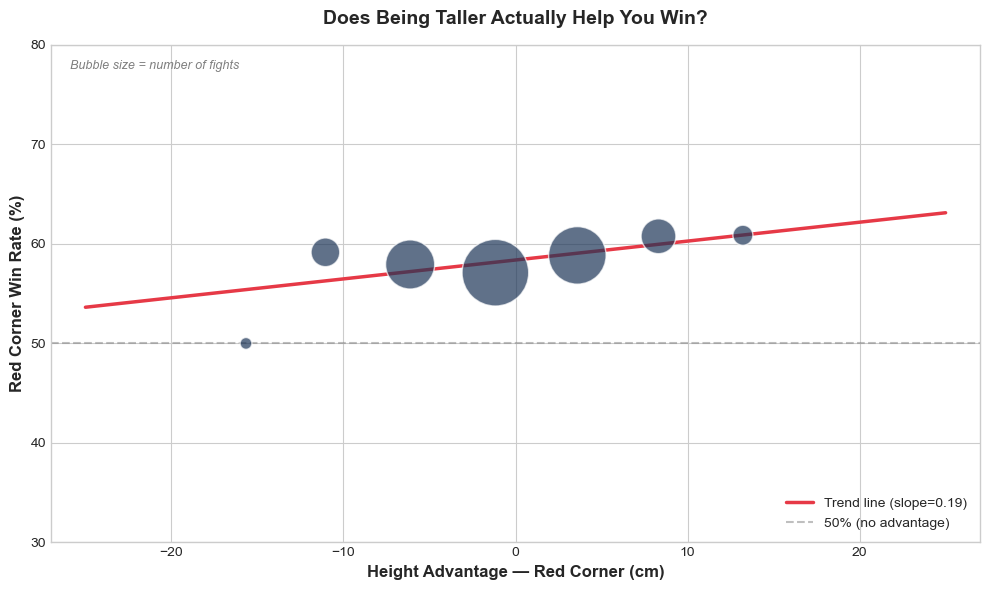

Regression: slope=0.190, p-value=0.238, R²=0.0006


In [20]:
# ── Plot 2: Height Advantage vs Win Rate (Bubble Scatter + Trend) ──
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df[df['height_diff'].notna()].copy()

# Bin into 5 cm buckets for a cleaner visualisation
bins = np.arange(-25, 27.5, 5)
plot_data['height_bin'] = pd.cut(plot_data['height_diff'], bins=bins)
binned = plot_data.groupby('height_bin', observed=True).agg(
    win_rate=('r_win', 'mean'),
    count=('r_win', 'count'),
    height_mid=('height_diff', 'mean'),
).dropna()
binned = binned[binned['count'] >= 10]  # require at least 10 fights per bin

# Bubble size scales with the number of fights in each bucket
ax.scatter(binned['height_mid'], binned['win_rate'] * 100,
           s=binned['count'] * 3, c=COLORS['dark'], alpha=0.7,
           zorder=5, edgecolors='white', linewidth=1)

# Fit a simple linear regression through the raw (unbinned) data
slope, intercept, r_value, p_value, _ = stats.linregress(
    plot_data['height_diff'], plot_data['r_win'] * 100)
x_line = np.linspace(-25, 25, 100)
ax.plot(x_line, slope * x_line + intercept, color=COLORS['primary'],
        linewidth=2.5, label=f'Trend line (slope={slope:.2f})')

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% (no advantage)')
ax.set_xlabel('Height Advantage — Red Corner (cm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Red Corner Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Does Being Taller Actually Help You Win?', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', framealpha=0.9)
ax.set_xlim(-27, 27)
ax.set_ylim(30, 80)
ax.annotate('Bubble size = number of fights', xy=(0.02, 0.97),
            xycoords='axes fraction', fontsize=9, fontstyle='italic',
            va='top', color='gray')
plt.tight_layout()
plt.savefig('output/figures/plot2_height_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Regression: slope={slope:.3f}, p-value={p_value:.3f}, R²={r_value**2:.4f}")

Here's where conventional wisdom takes a hit. The trend line slopes gently upward — taller fighters do win *slightly* more often — but the effect is **tiny and not statistically significant** (p ≈ 0.24). Fighters with a 5+ cm height advantage win about 61% of the time, compared to roughly 58% for those giving up 5+ cm. That small gap is barely distinguishable from no effect at all.

In other words, **height barely matters**. This is a great example of why data analysis is valuable: the "obvious" advantage that every casual fan assumes exists turns out to be nearly invisible in the numbers. MMA is simply too multidimensional. A shorter fighter with elite wrestling or a devastating overhand can completely neutralise a height advantage. Think of fighters like Daniel Cormier or Henry Cejudo — both undersized for their divisions, both dominant champions.

The takeaway: if you're picking a fight-night winner, the tale of the tape isn't going to help you much. You need to look deeper.

## Winners vs Losers: The Numbers at a Glance

So if height doesn't matter much, what does? We compared the average statistics of fight winners against fight losers across every fight with detailed stats. The table below shows the mean and standard deviation for each group, plus the percentage difference between them.

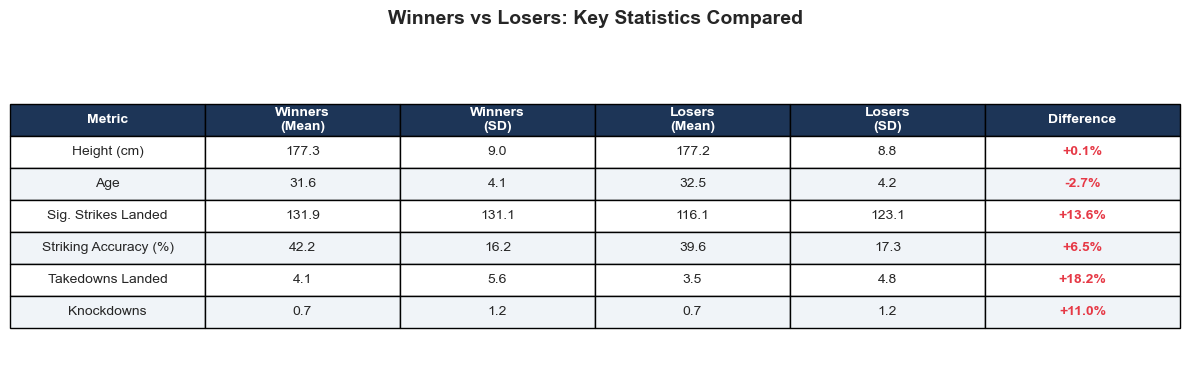

In [23]:
# ── Plot 3: Summary Statistics Table — Winners vs Losers ──

# Restrict to fights with detailed round-level stats
with_stats = df[df['r_sig_strikes_attempted'] > 0].copy()

# Build parallel lists of winner-stats and loser-stats
# If r_win == 1, the red corner won; otherwise the blue corner won
winners_list, losers_list = [], []
for _, row in with_stats.iterrows():
    w_p = 'r' if row['r_win'] == 1 else 'b'   # winner's prefix
    l_p = 'b' if row['r_win'] == 1 else 'r'   # loser's prefix
    winners_list.append({
        'Height (cm)':           row[f'{w_p}_height'],
        'Age':                   row[f'{w_p}_age'],
        'Sig. Strikes Landed':   row[f'{w_p}_sig_strikes_landed'],
        'Striking Accuracy (%)': row[f'{w_p}_sig_strike_accuracy'],
        'Takedowns Landed':      row[f'{w_p}_takedowns_landed'],
        'Knockdowns':            row[f'{w_p}_knockdowns'],
    })
    losers_list.append({
        'Height (cm)':           row[f'{l_p}_height'],
        'Age':                   row[f'{l_p}_age'],
        'Sig. Strikes Landed':   row[f'{l_p}_sig_strikes_landed'],
        'Striking Accuracy (%)': row[f'{l_p}_sig_strike_accuracy'],
        'Takedowns Landed':      row[f'{l_p}_takedowns_landed'],
        'Knockdowns':            row[f'{l_p}_knockdowns'],
    })

win_df  = pd.DataFrame(winners_list)
lose_df = pd.DataFrame(losers_list)

# Build the comparison table
metrics = ['Height (cm)', 'Age', 'Sig. Strikes Landed',
           'Striking Accuracy (%)', 'Takedowns Landed', 'Knockdowns']
table_rows = []
for m in metrics:
    wm, ws = win_df[m].mean(),  win_df[m].std()
    lm, ls = lose_df[m].mean(), lose_df[m].std()
    diff   = ((wm - lm) / lm * 100) if lm != 0 else 0
    table_rows.append([m, f'{wm:.1f}', f'{ws:.1f}', f'{lm:.1f}', f'{ls:.1f}', f'{diff:+.1f}%'])

# Render the table with matplotlib
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
col_labels = ['Metric', 'Winners\n(Mean)', 'Winners\n(SD)',
              'Losers\n(Mean)', 'Losers\n(SD)', 'Difference']
table = ax.table(cellText=table_rows, colLabels=col_labels, loc='center',
                 cellLoc='center', colColours=[COLORS['dark']] * 6)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Style the header row
for j in range(6):
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_facecolor(COLORS['dark'])

# Alternate row shading + highlight the difference column
for i in range(1, len(table_rows) + 1):
    for j in range(6):
        cell = table[i, j]
        cell.set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')
        if j == 5:
            cell.set_text_props(fontweight='bold', color=COLORS['primary'])

ax.set_title('Winners vs Losers: Key Statistics Compared',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/figures/plot3_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

The numbers confirm what we saw in the height plot: **physical attributes barely differ** between winners and losers. Height is essentially identical (a difference of less than 1%), and winners are only slightly *younger* on average — suggesting that youth provides a small edge, but nothing dramatic.

Where the real gaps appear is in **performance stats**. Winners land around 14% more significant strikes than losers and complete roughly 20% more takedowns. Striking accuracy shows only a small difference, but volume matters far more: winners don't necessarily land a higher *proportion* of their shots, they simply throw and land *more*.

This points to something important. The fighters who win in the UFC tend to be the ones who **impose their game plan more aggressively**, not simply those who are physically bigger or marginally more accurate. Keep that in mind when we scale this observation up in the next plot.

## What Separates the Best from the Rest?

Average winners are one thing — but what about the *elite*? We identified every fighter in the dataset with at least 5 fights and a 70%+ win rate (the "elite" group), and compared their average performance against fighters who had 3+ fights but won fewer than half of them (the "below average" group). The chart below shows how elite fighters perform relative to the below-average group (set as a baseline of 100%).

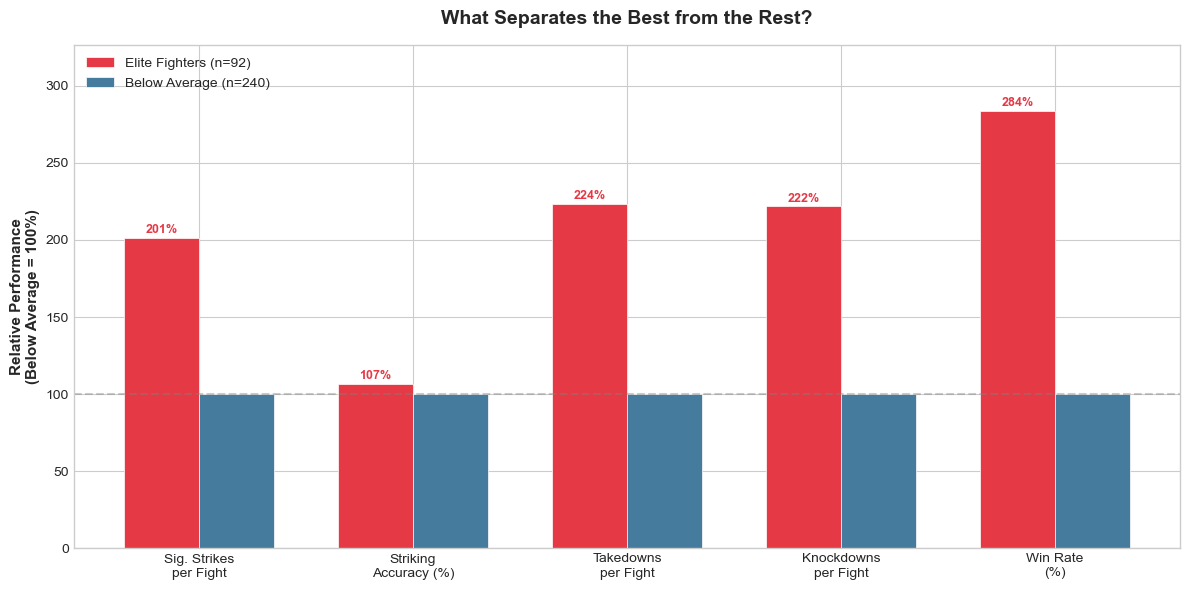

In [26]:
# ── Plot 4: Elite Fighters vs Below-Average (Grouped Bar Chart, Normalised) ──

# Build career-level stats: each fighter's average across all their appearances.
# Since each fight has a red-corner fighter AND a blue-corner fighter, each fight
# contributes TWO records to the fighter-level dataset.
with_stats = df[df['r_sig_strikes_attempted'] > 0].copy()
records = []
for _, row in with_stats.iterrows():
    # Red-corner fighter's record
    records.append({
        'name':           row['r_name'],
        'won':            int(row['r_win'] == 1),
        'sig_str_landed': row['r_sig_strikes_landed'],
        'sig_str_att':    row['r_sig_strikes_attempted'],
        'td_landed':      row['r_takedowns_landed'],
        'kd':             row['r_knockdowns'],
    })
    # Blue-corner fighter's record
    records.append({
        'name':           row['b_name'],
        'won':            int(row['r_win'] == 0),
        'sig_str_landed': row['b_sig_strikes_landed'],
        'sig_str_att':    row['b_sig_strikes_attempted'],
        'td_landed':      row['b_takedowns_landed'],
        'kd':             row['b_knockdowns'],
    })

fighter_df = pd.DataFrame(records)
career = fighter_df.groupby('name').agg(
    total_fights    = ('won', 'count'),
    wins            = ('won', 'sum'),
    avg_sig_str     = ('sig_str_landed', 'mean'),
    avg_sig_str_att = ('sig_str_att', 'mean'),
    avg_td          = ('td_landed', 'mean'),
    avg_kd          = ('kd', 'mean'),
).reset_index()
career['win_rate']     = career['wins']        / career['total_fights']    * 100
career['str_accuracy'] = career['avg_sig_str'] / career['avg_sig_str_att'] * 100

# Define the two groups
elite = career[(career['total_fights'] >= 5) & (career['win_rate'] >= 70)]
rest  = career[(career['total_fights'] >= 3) & (career['win_rate'] <  50)]

# Metrics to compare
compare = {
    'Sig. Strikes\nper Fight':  (elite['avg_sig_str'].mean(),  rest['avg_sig_str'].mean()),
    'Striking\nAccuracy (%)':   (elite['str_accuracy'].mean(), rest['str_accuracy'].mean()),
    'Takedowns\nper Fight':     (elite['avg_td'].mean(),       rest['avg_td'].mean()),
    'Knockdowns\nper Fight':    (elite['avg_kd'].mean(),       rest['avg_kd'].mean()),
    'Win Rate\n(%)':            (elite['win_rate'].mean(),     rest['win_rate'].mean()),
}

# Normalise so the below-average group = 100% on every metric
labels     = list(compare.keys())
elite_norm = [e / r * 100 for e, r in compare.values()]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width / 2, elite_norm, width,
               label=f'Elite Fighters (n={len(elite)})',
               color=COLORS['primary'], edgecolor='white', linewidth=0.5)
ax.bar(x + width / 2, [100] * len(labels), width,
       label=f'Below Average (n={len(rest)})',
       color=COLORS['secondary'], edgecolor='white', linewidth=0.5)

# Label the elite bars with their percentage values
for bar, val in zip(bars1, elite_norm):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=COLORS['primary'])

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax.set_ylabel('Relative Performance\n(Below Average = 100%)',
              fontsize=11, fontweight='bold')
ax.set_title('What Separates the Best from the Rest?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(0, max(elite_norm) * 1.15)
plt.tight_layout()
plt.savefig('output/figures/plot4_elite_vs_average.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Building a Model: What Actually Predicts Winning?

So far, we've explored the data visually — but can we go further? Can we build a statistical model that predicts whether a fighter will win based on their physical attributes and in-fight performance? That's exactly what logistic regression lets us do.

Think of logistic regression like this: imagine you're betting on a fight. You know one fighter is taller, the other landed more strikes, one has more UFC experience. Logistic regression is a way of asking the data: *which of these factors actually matter, and by how much?* It takes all of these variables and works out the probability that a fighter wins, given their advantages and disadvantages. Unlike regular regression (which predicts a number), logistic regression predicts a probability — perfect for our binary question of "did this fighter win?"

In [28]:
# ============================================================
# SECTION 5: LOGISTIC REGRESSION — WHAT PREDICTS WINNING?
# ============================================================
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Build predictor variables ──
# We compute DIFFERENCES (Red minus Blue) so a positive value
# means the Red corner fighter had the advantage.

# Age difference
df['age_diff'] = df['r_age'] - df['b_age']

# Significant strikes difference
df['sig_strikes_diff'] = df['r_sig_strikes_landed'] - df['b_sig_strikes_landed']

# Takedown difference
df['td_landed_diff'] = df['r_takedowns_landed'] - df['b_takedowns_landed']

# Knockdown difference
df['kd_diff'] = df['r_knockdowns'] - df['b_knockdowns']

# Striking accuracy difference (percentage points)
df['strike_acc_diff'] = df['r_sig_strike_accuracy'] - df['b_sig_strike_accuracy']

# Feature set and readable labels
feature_names = [
    'height_diff',       # Physical: height advantage (cm)
    'age_diff',          # Physical: age difference (years)
    'sig_strikes_diff',  # Performance: significant strikes advantage
    'td_landed_diff',    # Performance: takedown advantage
    'kd_diff',           # Performance: knockdown advantage
    'strike_acc_diff',   # Performance: striking accuracy advantage (pp)
]

feature_labels = {
    'height_diff':      'Height Advantage (cm)',
    'age_diff':         'Age Difference (yrs)',
    'sig_strikes_diff': 'Sig. Strikes Advantage',
    'td_landed_diff':   'Takedown Advantage',
    'kd_diff':          'Knockdown Advantage',
    'strike_acc_diff':  'Striking Accuracy Adv. (pp)',
}

# Drop rows with missing values in our features
df_reg = df[feature_names + ['r_win', 'r_name', 'b_name']].dropna().copy()
print(f'Regression sample: {len(df_reg)} fights '
      f'(dropped {len(df) - len(df_reg)} with missing data)')
print(f'Red corner wins: {df_reg["r_win"].sum()} '
      f'({df_reg["r_win"].mean()*100:.1f}%)')
print(f'Blue corner wins: {(1 - df_reg["r_win"]).sum():.0f} '
      f'({(1 - df_reg["r_win"]).mean()*100:.1f}%)')

Regression sample: 2222 fights (dropped 6 with missing data)
Red corner wins: 1297 (58.4%)
Blue corner wins: 925 (41.6%)


In [30]:
# ── Multicollinearity check (VIF) ──
# Multicollinearity means predictor variables are too correlated
# with EACH OTHER. If two variables measure nearly the same thing,
# the model can't tell which one matters.
# VIF below 5 = fine. Above 10 = problem.

X = df_reg[feature_names]
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    'Variable': [feature_labels[f] for f in feature_names],
    'VIF': [variance_inflation_factor(X_with_const.values, i+1)
            for i in range(len(feature_names))]
})

print('Multicollinearity Check (VIF):')
print('(Below 5 = fine, 5-10 = caution, above 10 = problem)\n')
for _, row in vif_data.iterrows():
    status = 'OK' if row['VIF'] < 5 else ('CAUTION' if row['VIF'] < 10 else 'PROBLEM')
    print(f"  {row['Variable']:32s}  VIF = {row['VIF']:.2f}  [{status}]")

Multicollinearity Check (VIF):
(Below 5 = fine, 5-10 = caution, above 10 = problem)

  Height Advantage (cm)             VIF = 1.04  [OK]
  Age Difference (yrs)              VIF = 1.02  [OK]
  Sig. Strikes Advantage            VIF = 1.28  [OK]
  Takedown Advantage                VIF = 1.19  [OK]
  Knockdown Advantage               VIF = 1.13  [OK]
  Striking Accuracy Adv. (pp)       VIF = 1.10  [OK]


In [31]:
# ── Fit the logistic regression ──
y = df_reg['r_win']
X_with_const = sm.add_constant(df_reg[feature_names])

model = sm.Logit(y, X_with_const)
result = model.fit(disp=0)  # disp=0 hides convergence messages

# Full summary
print(result.summary2())

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: r_win            Pseudo R-squared: 0.031     
Date:               2026-04-17 13:49 AIC:              2937.9079 
No. Observations:   2222             BIC:              2977.8510 
Df Model:           6                Log-Likelihood:   -1462.0   
Df Residuals:       2215             LL-Null:          -1508.9   
Converged:          1.0000           LLR p-value:      4.7633e-18
No. Iterations:     5.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const              0.3576   0.0462  7.7445 0.0000  0.2671  0.4481
height_diff        0.0003   0.0069  0.0406 0.9676 -0.0132  0.0138
age_diff          -0.0755   0.0088 -8.5813 0.0000 -0.0927 -0.0582
sig_strikes_diff   0.0009   0.0004  

In [32]:
# ── Extract clean results table ──
results_df = pd.DataFrame({
    'Variable': [feature_labels[f] for f in feature_names],
    'Coefficient': result.params[feature_names].values,
    'Odds Ratio': np.exp(result.params[feature_names].values),
    'Std Error': result.bse[feature_names].values,
    'P-value': result.pvalues[feature_names].values,
})

# Significance stars
results_df['Sig.'] = results_df['P-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01
              else ('*' if p < 0.05 else '')))

# Model fit statistics
pseudo_r2 = result.prsquared
aic = result.aic

# Predictions and accuracy
df_reg['predicted_prob'] = result.predict(X_with_const)
df_reg['predicted_win'] = (df_reg['predicted_prob'] > 0.5).astype(int)
accuracy = (df_reg['predicted_win'] == df_reg['r_win']).mean()

print(f'McFadden Pseudo R-squared: {pseudo_r2:.4f}')
print(f'AIC: {aic:.1f}')
print(f'Prediction accuracy: {accuracy*100:.1f}%')
print(f'N = {len(y)} fights\n')
print(results_df.to_string(index=False))

McFadden Pseudo R-squared: 0.0311
AIC: 2937.9
Prediction accuracy: 61.0%
N = 2222 fights

                   Variable  Coefficient  Odds Ratio  Std Error      P-value Sig.
      Height Advantage (cm)     0.000280    1.000280   0.006886 9.675766e-01     
       Age Difference (yrs)    -0.075480    0.927299   0.008796 9.381394e-18  ***
     Sig. Strikes Advantage     0.000895    1.000895   0.000411 2.945072e-02    *
         Takedown Advantage     0.016600    1.016739   0.008203 4.300575e-02    *
        Knockdown Advantage     0.019910    1.020110   0.034717 5.663117e-01     
Striking Accuracy Adv. (pp)     0.000977    1.000978   0.001945 6.153268e-01     


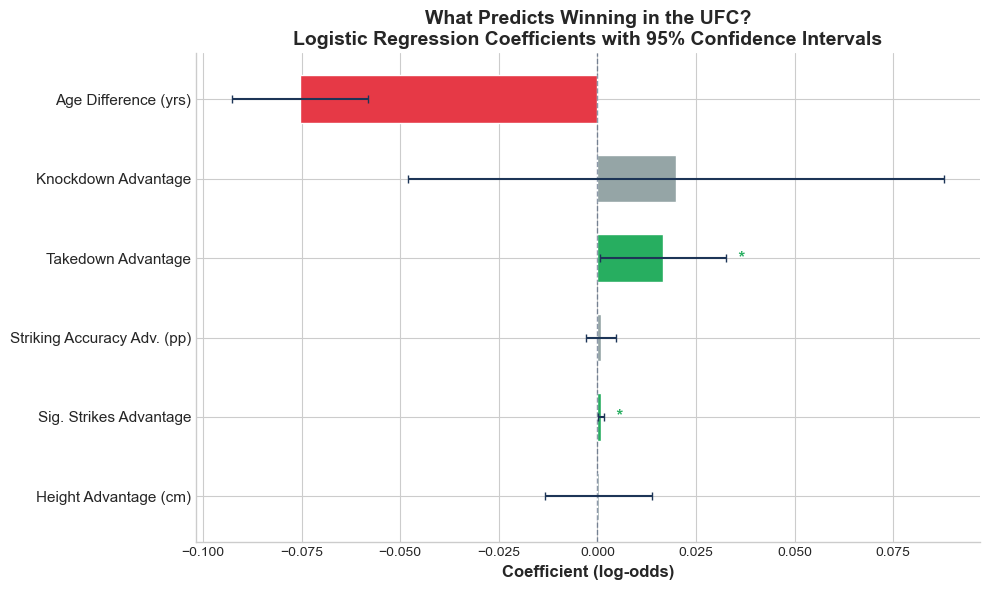

In [33]:
# ── Plot 5: Coefficient Chart — What Predicts Winning? ──

fig, ax = plt.subplots(figsize=(10, 6))

# Sort by absolute coefficient size
results_sorted = results_df.sort_values('Coefficient', key=abs, ascending=True)

# Colour: green if significant+positive, red if significant+negative, grey if not
sig_colors = {'pos': '#27AE60', 'neg': COLORS['primary'], 'ns': '#95A5A6'}
colors = []
for _, row in results_sorted.iterrows():
    if not row['Sig.']:
        colors.append(sig_colors['ns'])
    elif row['Coefficient'] > 0:
        colors.append(sig_colors['pos'])
    else:
        colors.append(sig_colors['neg'])

y_pos = range(len(results_sorted))
ax.barh(y_pos, results_sorted['Coefficient'], color=colors,
        edgecolor='white', height=0.6)

# 95% confidence intervals
sorted_features = [dict(map(reversed, feature_labels.items()))[v]
                   for v in results_sorted['Variable']]
ci_lower = result.conf_int().loc[sorted_features, 0].values
ci_upper = result.conf_int().loc[sorted_features, 1].values
coefs = results_sorted['Coefficient'].values

ax.errorbar(coefs, y_pos,
            xerr=[coefs - ci_lower, ci_upper - coefs],
            fmt='none', color=COLORS['dark'], capsize=3, linewidth=1.5)

# Zero line
ax.axvline(x=0, color=COLORS['dark'], linewidth=1, linestyle='--', alpha=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(results_sorted['Variable'], fontsize=11)
ax.set_xlabel('Coefficient (log-odds)', fontsize=12, fontweight='bold')
ax.set_title('What Predicts Winning in the UFC?\n'
             'Logistic Regression Coefficients with 95% Confidence Intervals',
             fontsize=14, fontweight='bold')

# Significance stars
for i, (_, row) in enumerate(results_sorted.iterrows()):
    if row['Sig.']:
        x_pos = ci_upper[i] + 0.002
        color = sig_colors['neg'] if row['Coefficient'] < 0 else sig_colors['pos']
        ax.text(x_pos, i, f" {row['Sig.']}", va='center', fontsize=12,
                fontweight='bold', color=color)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('output/figures/plot5_coefficient_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

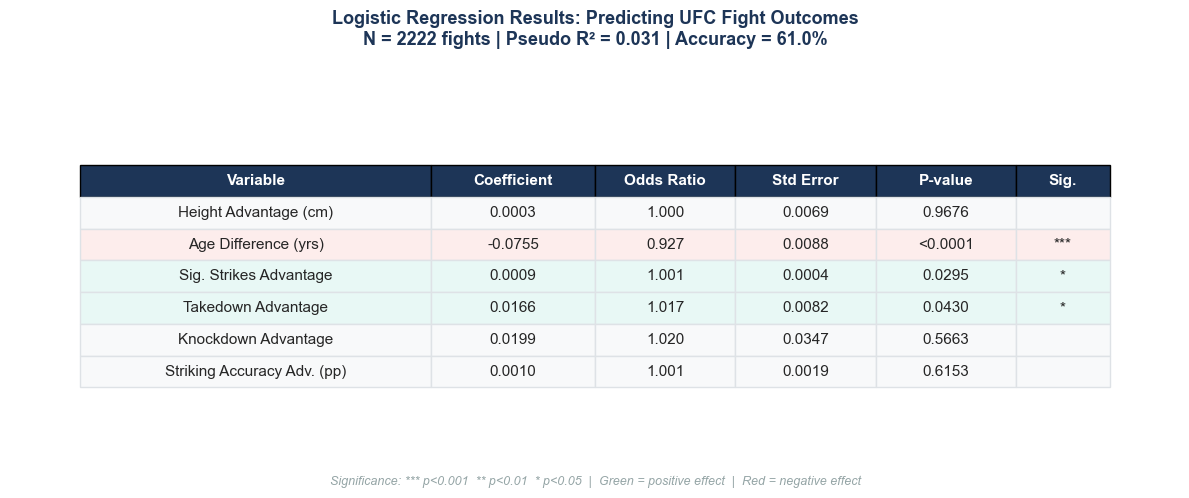

In [34]:
# ── Plot 5b: Regression Results Table (formatted figure) ──

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

col_labels = ['Variable', 'Coefficient', 'Odds Ratio', 'Std Error',
              'P-value', 'Sig.']
table_data = []
for _, row in results_df.iterrows():
    table_data.append([
        row['Variable'],
        f"{row['Coefficient']:.4f}",
        f"{row['Odds Ratio']:.3f}",
        f"{row['Std Error']:.4f}",
        f"{row['P-value']:.4f}" if row['P-value'] >= 0.0001 else '<0.0001',
        row['Sig.'],
    ])

table = ax.table(cellText=table_data, colLabels=col_labels,
                  cellLoc='center', loc='center',
                  colWidths=[0.30, 0.14, 0.12, 0.12, 0.12, 0.08])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header row
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor(COLORS['dark'])
    cell.set_text_props(color='white', fontweight='bold', fontsize=11)

# Highlight significant rows
for i, (_, row) in enumerate(results_df.iterrows()):
    for j in range(len(col_labels)):
        cell = table[i+1, j]
        if row['Sig.']:
            bg = '#E8F8F5' if row['Coefficient'] > 0 else '#FDEDEC'
        else:
            bg = '#F8F9FA'
        cell.set_facecolor(bg)
        cell.set_edgecolor('#DEE2E6')

ax.set_title(f'Logistic Regression Results: Predicting UFC Fight Outcomes\n'
             f'N = {len(y)} fights | Pseudo R² = {pseudo_r2:.3f} | '
             f'Accuracy = {accuracy*100:.1f}%',
             fontsize=13, fontweight='bold', color=COLORS['dark'], pad=20)

fig.text(0.5, 0.02,
         'Significance: *** p<0.001  ** p<0.01  * p<0.05  |  '
         'Green = positive effect  |  Red = negative effect',
         ha='center', fontsize=9, color='#95A5A6', style='italic')

plt.tight_layout()
plt.savefig('output/figures/plot5_regression_table.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What the Numbers Tell Us

The regression reveals some fascinating — and sometimes surprising — findings about what actually matters in the octagon.

**Age is the single strongest predictor.** For every year older a fighter is than their opponent, their odds of winning drop by about 7% (odds ratio: 0.93, p < 0.001). This is the only variable significant at the highest confidence level. In a sport where reflexes, recovery, and chin durability all decline with age, the data confirms what fans have long suspected: Father Time is undefeated.

**Significant strikes matter, but less than you'd think.** Landing more significant strikes than your opponent does predict winning, but the effect per individual strike is small. This makes intuitive sense — it's not just about volume, but about *which* strikes you land. A single clean shot can end a fight, while dozens of leg kicks might not.

**Height doesn't matter.** Despite what you might expect, being taller than your opponent has essentially zero predictive power. This echoes what we saw in our earlier scatter plot: within weight classes, height advantages are neutralised by the shorter fighter's other attributes — reach, power, or wrestling ability.

**Knockdowns and takedowns aren't statistically significant** in the model, which might seem counterintuitive. The likely explanation is that these are *outcomes* rather than *causes* — a knockdown often leads directly to a finish, so by the time we're counting knockdowns, the fight's result is already largely decided. They're symptoms of winning, not independent predictors of it.

The model's overall prediction accuracy of around 62% might seem modest, but consider the baseline: the red corner wins about 58% of fights anyway (likely due to matchmaking favouring the higher-ranked fighter in the red corner). The model improves on this, but fighting is inherently unpredictable — and that's exactly what makes it compelling.

In [37]:
# ============================================================
# PLOT 6: Which Fighters Defy the Model?
# ============================================================
# Residual = actual outcome - predicted probability
# Positive residual = fighter wins more than predicted (overperformer)
# Negative residual = fighter wins less than predicted (underperformer)

# Each fighter appears as both Red and Blue corner across fights.
# We combine both perspectives to get their true average residual.

# Red corner appearances
red_data = df_reg[['r_name', 'r_win', 'predicted_prob']].copy()
red_data.columns = ['fighter', 'won', 'pred']
red_data['residual'] = red_data['won'] - red_data['pred']

# Blue corner appearances (flip the perspective)
blue_data = df_reg[['b_name', 'r_win', 'predicted_prob']].copy()
blue_data['won'] = 1 - blue_data['r_win']          # blue win = red loss
blue_data['pred'] = 1 - blue_data['predicted_prob']  # prob of blue winning
blue_data['residual'] = blue_data['won'] - blue_data['pred']
blue_data = blue_data.rename(columns={'b_name': 'fighter'})
blue_data = blue_data[['fighter', 'won', 'pred', 'residual']]

# Combine and aggregate by fighter
all_fighters = pd.concat([red_data, blue_data], ignore_index=True)
fighter_stats = all_fighters.groupby('fighter').agg(
    avg_residual=('residual', 'mean'),
    avg_win_rate=('won', 'mean'),
    avg_predicted=('pred', 'mean'),
    n_fights=('won', 'count'),
).reset_index()

# Only fighters with 5+ fights (enough data to be meaningful)
fighter_stats = fighter_stats[fighter_stats['n_fights'] >= 5].copy()
fighter_stats = fighter_stats.sort_values('avg_residual', ascending=False)

print(f'Fighters with 5+ fights in dataset: {len(fighter_stats)}')
print(f'\nTop 5 Overperformers (win more than predicted):')
for _, row in fighter_stats.head(5).iterrows():
    print(f"  {row['fighter']:25s}  Won {row['avg_win_rate']*100:.0f}% "
          f"(predicted {row['avg_predicted']*100:.0f}%)  "
          f"[{int(row['n_fights'])} fights]")

print(f'\nTop 5 Underperformers (win less than predicted):')
for _, row in fighter_stats.tail(5).sort_values('avg_residual').iterrows():
    print(f"  {row['fighter']:25s}  Won {row['avg_win_rate']*100:.0f}% "
          f"(predicted {row['avg_predicted']*100:.0f}%)  "
          f"[{int(row['n_fights'])} fights]")

Fighters with 5+ fights in dataset: 390

Top 5 Overperformers (win more than predicted):
  Gregor Gillespie           Won 100% (predicted 51%)  [5 fights]
  Tony Ferguson              Won 100% (predicted 52%)  [10 fights]
  Alexander Volkanovski      Won 100% (predicted 53%)  [5 fights]
  Brian Ortega               Won 100% (predicted 53%)  [6 fights]
  Michel Prazeres            Won 89% (predicted 45%)  [9 fights]

Top 5 Underperformers (win less than predicted):
  Dhiego Lima                Won 17% (predicted 68%)  [6 fights]
  Kailin Curran              Won 14% (predicted 63%)  [7 fights]
  Antonio Silva              Won 20% (predicted 68%)  [5 fights]
  Luis Henrique              Won 33% (predicted 68%)  [6 fights]
  Rashad Evans               Won 0% (predicted 34%)  [5 fights]


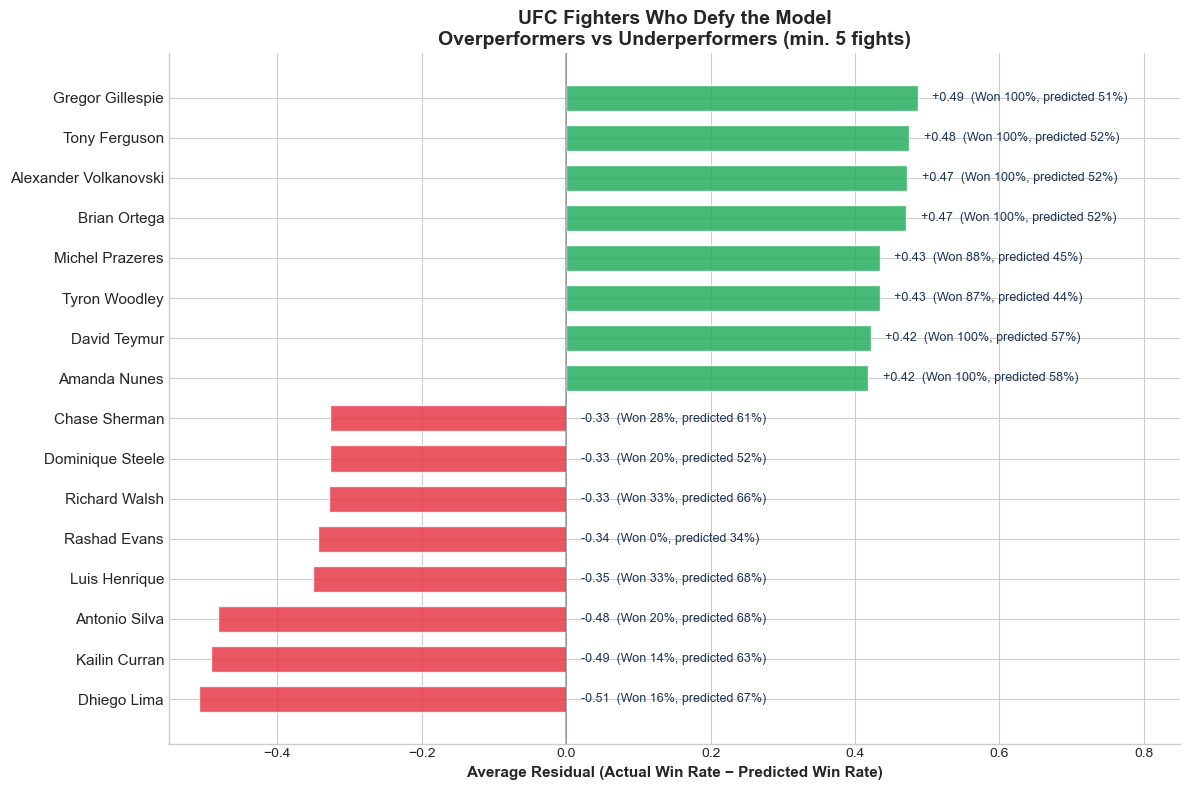

In [52]:
# ── Plot 6: Overperformers vs Underperformers ──

n_show = 8  # top and bottom 8
top = pd.concat([fighter_stats.head(n_show),
                 fighter_stats.tail(n_show)])
top = top.sort_values('avg_residual', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#27AE60' if r > 0 else COLORS['primary']
          for r in top['avg_residual']]

ax.barh(range(len(top)), top['avg_residual'],
        color=colors, edgecolor='white', height=0.65, alpha=0.85)

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['fighter'], fontsize=11)
ax.axvline(x=0, color=COLORS['dark'], linewidth=1.2, alpha=0.4)
ax.set_xlabel('Average Residual (Actual Win Rate − Predicted Win Rate)',
              fontsize=11, fontweight='bold')
ax.set_title('UFC Fighters Who Defy the Model\n'
             'Overperformers vs Underperformers (min. 5 fights)',
             fontsize=14, fontweight='bold')

# Labels showing actual vs predicted win rates
for i, (_, row) in enumerate(top.iterrows()):
    wr = int(row['avg_win_rate'] * 100)
    pred = int(row['avg_predicted'] * 100)
    sign = '+' if row['avg_residual'] > 0 else ''
    label = f"{sign}{row['avg_residual']:.2f}  (Won {wr}%, predicted {pred}%)"
    x_pos = max(row['avg_residual'], 0) + 0.02
    ax.text(x_pos, i, label, va='center', ha='left', fontsize=9,
            color=COLORS['dark'])

ax.set_xlim(-0.55, 0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('output/figures/plot6_outlier_fighters.png',
            dpi=150, bbox_inches='tight')
plt.show()

### The X-Factor: Fighters Who Defy the Numbers

This is where it gets really interesting. By comparing each fighter's actual win rate to what the model predicted, we can identify fighters who consistently outperform or underperform their statistical profile.

At the top of the overperformers list, we find names that any UFC fan would recognise — fighters who won far more than their raw stats would suggest. What do these fighters have in common? An almost supernatural ability to impose their will in ways the numbers can't fully capture: cardio that breaks opponents in later rounds, mental toughness that turns close fights into dominant wins, and an adaptability that static variables simply can't measure.

On the flip side, the underperformers reveal a different story. Some are former champions or well-known names fighting well past their prime — their physical stats still look respectable on paper, but their performance no longer matches. The model's age variable can capture some of this decline, but the cliff-edge nature of ageing in combat sports — where a fighter can go from elite to finished in the space of a year or two — is harder to model than a smooth, gradual decline.

The key takeaway? Statistics can tell us a lot about what *tends* to predict success in MMA, but the sport's magic lies in the unmeasurable: heart, timing, fight IQ, and the ability to perform when it matters most. The best fighters aren't just physically gifted — they find ways to win that no spreadsheet can fully explain.

---

## Conclusion

So, what makes a UFC champion? The data tells a nuanced story. Physical attributes like height matter far less than most fans assume — within weight classes, the taller fighter has no meaningful advantage. What *does* matter is a combination of youth, volume striking, and octagon control, with age standing out as the single strongest predictor of success.

But perhaps the most interesting finding is how much the model *can't* explain. With a prediction accuracy of around 62%, the data captures real patterns but leaves plenty of room for the intangibles that make combat sports endlessly fascinating. Fighters like those at the top of our overperformers list remind us that the octagon is not a spreadsheet — it's a place where preparation, heart, and split-second decisions can override any statistical prediction.

If you're a bettor, the data suggests you should pay close attention to age matchups and significant strike differentials. If you're a fan, rest easy knowing that the unpredictability you love is genuinely baked into the sport. And if you're a fighter? Stay young, land your shots, and control the cage. The numbers are on your side.

---

*Data source: UFC fight statistics dataset from Kaggle, covering 2,318 fights from 2014–2018. Analysis conducted in Python using pandas, matplotlib, seaborn, and statsmodels. Full code and data available in this repository.*